<a href="https://colab.research.google.com/github/akhilrattan/machine-learning/blob/main/transferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
datasets = {
    "Original": {

    "train": "/content/drive/MyDrive/Research_Assignment/original_split/train",
    "validation": "/content/drive/MyDrive/Research_Assignment/original_split/val",
    "test": "/content/drive/MyDrive/Research_Assignment/original_split/test"
    },

    "Quality_Degraded": {
        "train": "/content/drive/MyDrive/Research_Assignment/quality_degradation_split/train",
        "validation": "/content/drive/MyDrive/Research_Assignment/quality_degradation_split/val",
        "test": "/content/drive/MyDrive/Research_Assignment/quality_degradation_split/test"
    },

    "Illumination": {
        "train": "/content/drive/MyDrive/Research_Assignment/Illumination Variation_split/train",
        "validation":"/content/drive/MyDrive/Research_Assignment/Illumination Variation_split/val",
        "test": "/content/drive/MyDrive/Research_Assignment/Illumination Variation_split/test"
    }
}

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
data_generators = {}

for dataset_name, paths in datasets.items():

    train_generator = train_datagen.flow_from_directory(
        paths["train"],
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True
    )

    validation_generator = val_datagen.flow_from_directory(
        paths["validation"],
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_generator = test_datagen.flow_from_directory(
        paths["test"],
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    data_generators[dataset_name] = {
        "train": train_generator,
        "validation": validation_generator,
        "test": test_generator
    }

    print(f"{dataset_name} dataset loaded successfully")

Found 3323 images belonging to 9 classes.
Found 710 images belonging to 9 classes.
Found 719 images belonging to 9 classes.
Original dataset loaded successfully
Found 3323 images belonging to 9 classes.
Found 710 images belonging to 9 classes.
Found 719 images belonging to 9 classes.
Quality_Degraded dataset loaded successfully
Found 3323 images belonging to 9 classes.
Found 710 images belonging to 9 classes.
Found 719 images belonging to 9 classes.
Illumination dataset loaded successfully


In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

In [7]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
for layer in base_model.layers:
    layer.trainable = False

In [9]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)

x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.3)(x)

output = Dense(9, activation='softmax')(x)

In [10]:
vgg16_model = Model(
    inputs=base_model.input,
    outputs=output
)
vgg16_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,110,985 (57.64 MB)

 Trainable params: 396,297 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
from tensorflow.keras.models import clone_model
from tensorflow.keras.optimizers import Adam

# Dictionary to store trained models
models = {}

# Dictionary to store training history
history = {}

EPOCHS = 5

for dataset_name, generators in data_generators.items():

    print("=" * 60)
    print(f"Training VGG16 on {dataset_name} Dataset")
    print("=" * 60)

    # Create a fresh copy of the VGG16 model
    model = clone_model(vgg16_model)

    # Copy pretrained ImageNet weights
    model.set_weights(vgg16_model.get_weights())

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the model
    history[dataset_name] = model.fit(
        generators["train"],
        validation_data=generators["validation"],
        epochs=EPOCHS,
        verbose=1
    )

    # Save trained model in dictionary
    models[dataset_name] = model

    # Save model to disk
    model.save(f"VGG16_{dataset_name}.keras")

Training VGG16 on Original Dataset
Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1234s 12s/step - accuracy: 0.3027 - loss: 1.8640 - val_accuracy: 0.4394 - val_loss: 1.4964
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.4412 - loss: 1.4939 - val_accuracy: 0.5606 - val_loss: 1.2818
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 209ms/step - accuracy: 0.5017 - loss: 1.3378 - val_accuracy: 0.5972 - val_loss: 1.1718
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 202ms/step - accuracy: 0.5390 - loss: 1.2456 - val_accuracy: 0.6085 - val_loss: 1.1550
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.5751 - loss: 1.1552 - val_accuracy: 0.6324 - val_loss: 1.0538
Training VGG16 on Quality_Degraded Dataset
Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1325s 13s/step - accuracy: 0.2624 - loss: 1.9796 - val_accuracy: 0.3225 - val_loss: 1.7271
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.3641 - loss: 1.6847 - val_accuracy: 0.4282 - val_loss: 1.5381
Epoch 3/5
10

In [12]:
fine_tune_history = {}

for dataset_name, model in models.items():
    print(f"\nFine-Tuning VGG16 on {dataset_name} Dataset...\n")

    # Freeze all layers
    for layer in model.layers:
        layer.trainable = False

    # Unfreeze last 5 layers
    for layer in model.layers[-5:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    fine_tune_history[dataset_name] = model.fit(
        data_generators[dataset_name]["train"],
        validation_data=data_generators[dataset_name]["validation"],
        epochs=5
    )


Fine-Tuning VGG16 on Original Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 33s 271ms/step - accuracy: 0.5961 - loss: 1.0984 - val_accuracy: 0.6690 - val_loss: 1.0111
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step - accuracy: 0.6241 - loss: 1.0532 - val_accuracy: 0.6662 - val_loss: 0.9962
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step - accuracy: 0.6208 - loss: 1.0530 - val_accuracy: 0.6746 - val_loss: 0.9891
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step - accuracy: 0.6175 - loss: 1.0517 - val_accuracy: 0.6746 - val_loss: 0.9843
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.6199 - loss: 1.0428 - val_accuracy: 0.6718 - val_loss: 0.9811

Fine-Tuning VGG16 on Quality_Degraded Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 31s 255ms/step - accuracy: 0.4983 - loss: 1.3669 - val_accuracy: 0.5099 - val_loss: 1.3117
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 34s 218ms/step - accuracy: 0.5086 - loss: 1.3504 - val_accuracy: 0.5211 - val_loss: 1.3

In [13]:
test_results = {}

for dataset_name, model in models.items():

    print(f"\nEvaluating {dataset_name} Dataset...\n")

    loss, accuracy = model.evaluate(
        data_generators[dataset_name]["test"],
        verbose = 0
    )

    test_results[dataset_name] = {
        "Loss": loss,
        "Accuracy": accuracy
    }

    print(f"Test Accuracy: {accuracy:.4f}")


Evaluating Original Dataset...

Test Accuracy: 0.6467

Evaluating Quality_Degraded Dataset...

Test Accuracy: 0.5396

Evaluating Illumination Dataset...

Test Accuracy: 0.5522


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = {}
true_labels = {}

for dataset_name, model in models.items():

    test_generator = data_generators[dataset_name]["test"]

    test_generator.reset()

    y_pred = model.predict(test_generator)

    y_pred = np.argmax(y_pred, axis=1)

    y_true = test_generator.classes

    predictions[dataset_name] = y_pred
    true_labels[dataset_name] = y_true

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step


In [15]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

metrics = {}

for dataset_name in predictions.keys():

    metrics[dataset_name] = {

        "Accuracy": accuracy_score(
            true_labels[dataset_name],
            predictions[dataset_name]
        ),

        "Precision": precision_score(
            true_labels[dataset_name],
            predictions[dataset_name],
            average='weighted'
        ),

        "Recall": recall_score(
            true_labels[dataset_name],
            predictions[dataset_name],
            average='weighted'
        ),

        "F1 Score": f1_score(
            true_labels[dataset_name],
            predictions[dataset_name],
            average='weighted'
        )
    }

In [45]:
import pandas as pd

# Convert dictionary to DataFrame
metrics_df = pd.DataFrame(metrics).T

# Set dataset names as index
metrics_df.index.name = "Dataset"

# Display the table
print(metrics_df)

# Save to CSV
metrics_df.to_csv(
    "/content/drive/MyDrive/Research_Assignment/Results/vgg16.csv"
)

print("CSV file saved successfully!")

                  Accuracy  Precision    Recall  F1 Score
Dataset                                                  
Original          0.646732   0.645668  0.646732  0.637902
Quality_Degraded  0.539638   0.539660  0.539638  0.511227
Illumination      0.552156   0.542567  0.552156  0.525583
CSV file saved successfully!


<Figure size 800x800 with 0 Axes>

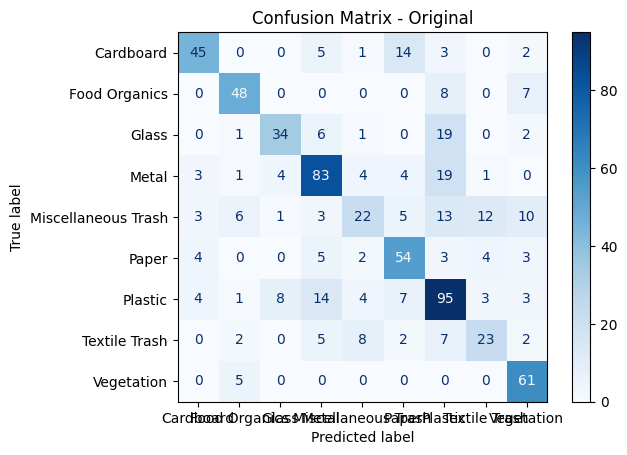

<Figure size 800x800 with 0 Axes>

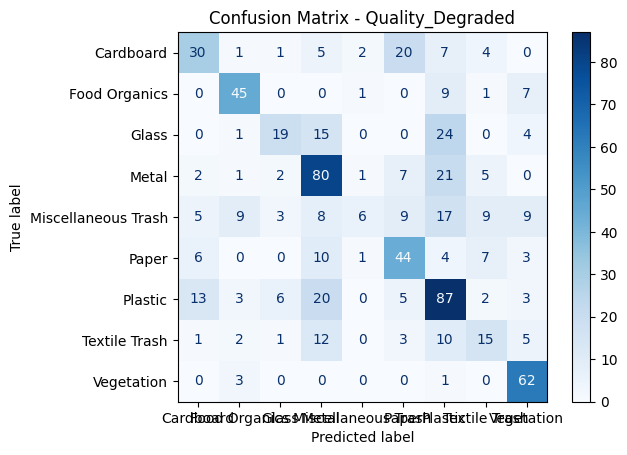

<Figure size 800x800 with 0 Axes>

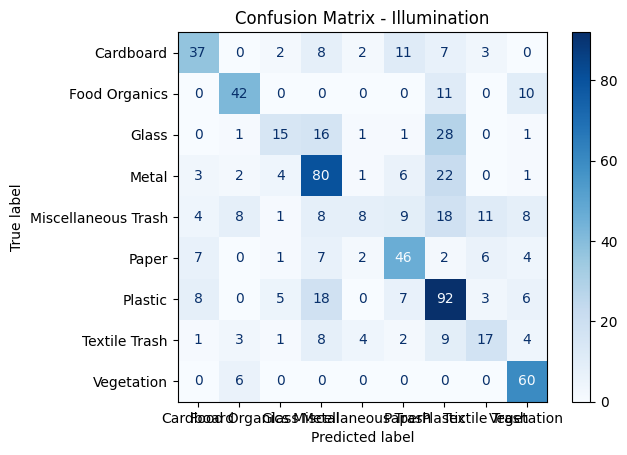

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for dataset_name in predictions:

    cm = confusion_matrix(
        true_labels[dataset_name],
        predictions[dataset_name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(
            data_generators[dataset_name]["train"].class_indices.keys()
        )
    )

    plt.figure(figsize=(8,8))
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()

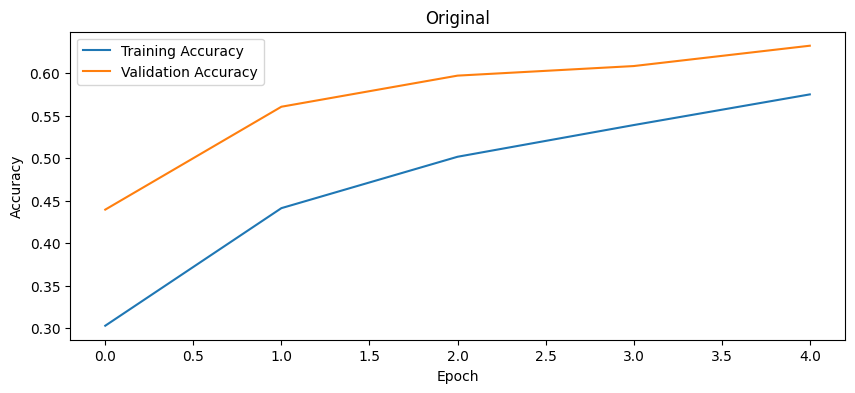

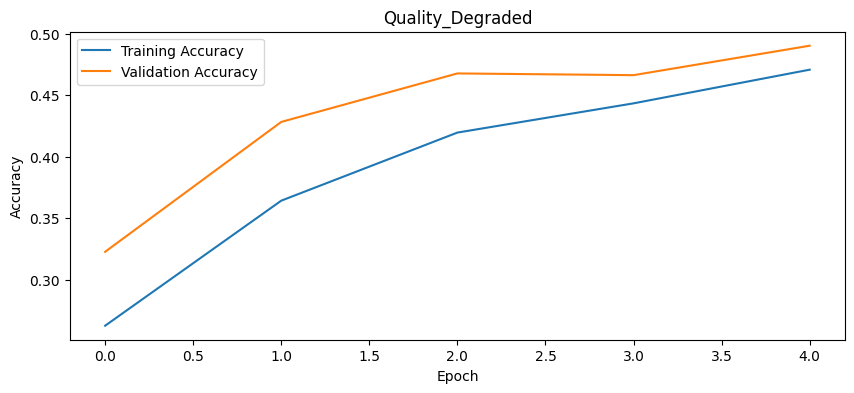

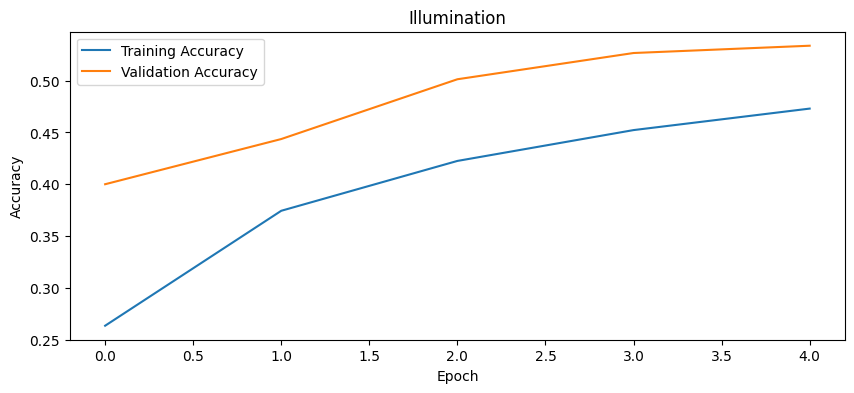

In [17]:
for dataset_name, hist in history.items():

    plt.figure(figsize=(10,4))

    plt.plot(hist.history["accuracy"], label="Training Accuracy")
    plt.plot(hist.history["val_accuracy"], label="Validation Accuracy")

    plt.title(dataset_name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

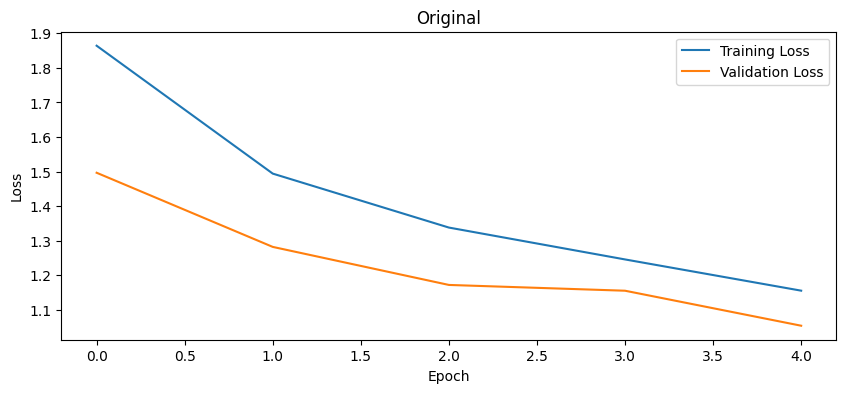

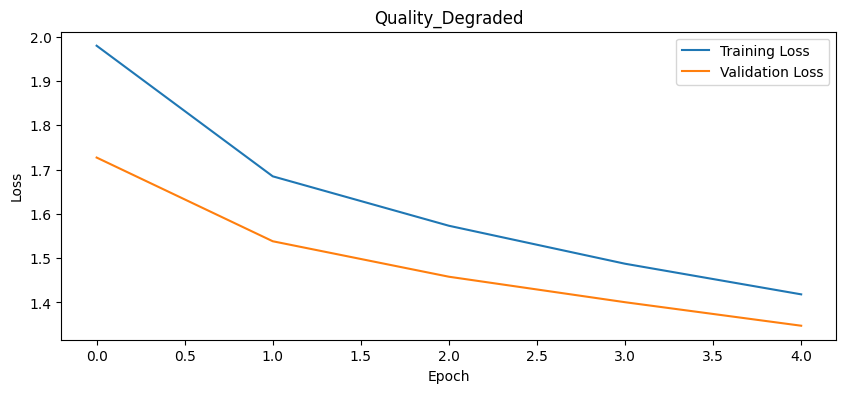

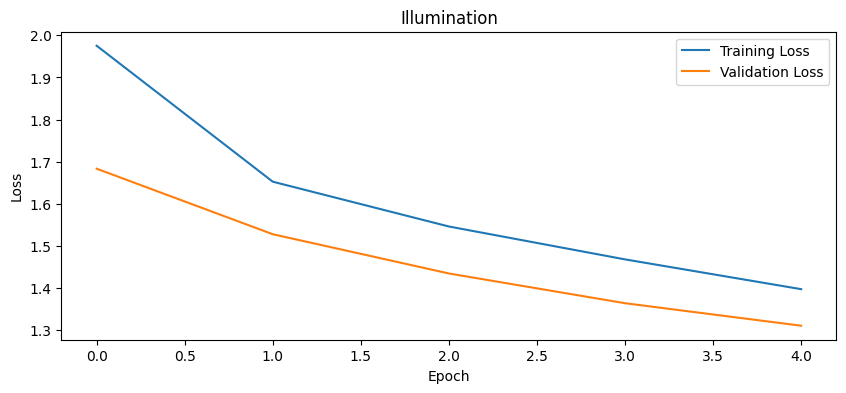

In [18]:
for dataset_name, hist in history.items():

    plt.figure(figsize=(10,4))

    plt.plot(hist.history["loss"], label="Training Loss")
    plt.plot(hist.history["val_loss"], label="Validation Loss")

    plt.title(dataset_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

mobilenet


In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [20]:
mobilenet_history = {}

mobilenet_models = {}

for dataset_name, generators in data_generators.items():

    print(f"\nTraining MobileNetV2 on {dataset_name} Dataset...\n")

    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    # Freeze pretrained layers
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)

    output = Dense(9, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    mobilenet_history[dataset_name] = model.fit(
        generators["train"],
        validation_data=generators["validation"],
        epochs=5
    )

    mobilenet_models[dataset_name] = model


Training MobileNetV2 on Original Dataset...

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 68s 452ms/step - accuracy: 0.4586 - loss: 1.4909 - val_accuracy: 0.6310 - val_loss: 1.0315
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - accuracy: 0.6262 - loss: 1.0324 - val_accuracy: 0.6887 - val_loss: 0.8663
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step - accuracy: 0.6885 - loss: 0.8773 - val_accuracy: 0.6873 - val_loss: 0.8508
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 0.7436 - loss: 0.7263 - val_accuracy: 0.7070 - val_loss: 0.8225
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.7791 - loss: 0.6244 - val_accuracy: 0.7352 - val_loss: 0.7959

Training MobileNetV2 on Quality_Degraded Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 42s 298ms/step - accuracy: 0.3768 - loss: 1.7410 - val_accuracy: 0.5521 - val_loss: 1.3099
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.516

In [21]:
mobilenet_finetune_history = {}

for dataset_name, model in mobilenet_models.items():

    print(f"\nFine-Tuning MobileNetV2 on {dataset_name} Dataset...\n")

    # Freeze all layers
    for layer in model.layers:
        layer.trainable = False

    # Unfreeze last 20 layers
    for layer in model.layers[-20:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    mobilenet_finetune_history[dataset_name] = model.fit(
        data_generators[dataset_name]["train"],
        validation_data=data_generators[dataset_name]["validation"],
        epochs=5
    )


Fine-Tuning MobileNetV2 on Original Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 49s 324ms/step - accuracy: 0.6771 - loss: 0.9083 - val_accuracy: 0.7085 - val_loss: 0.7953
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.7454 - loss: 0.7390 - val_accuracy: 0.7254 - val_loss: 0.7913
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 0.7668 - loss: 0.6691 - val_accuracy: 0.7324 - val_loss: 0.7854
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.7788 - loss: 0.6162 - val_accuracy: 0.7451 - val_loss: 0.7769
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.8005 - loss: 0.5777 - val_accuracy: 0.7423 - val_loss: 0.7683

Fine-Tuning MobileNetV2 on Quality_Degraded Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 48s 315ms/step - accuracy: 0.5134 - loss: 1.3818 - val_accuracy: 0.6141 - val_loss: 1.0712
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 0.5949 - loss: 1.1396 - val_accuracy: 0.6254 - v

In [22]:
mobilenet_results = {}

for dataset_name, model in mobilenet_models.items():

    print(f"\nEvaluating {dataset_name}\n")

    loss, accuracy = model.evaluate(
        data_generators[dataset_name]["test"]
    )

    mobilenet_results[dataset_name] = {
        "Loss": loss,
        "Accuracy": accuracy
    }

    print(f"Test Accuracy : {accuracy:.4f}")


Evaluating Original

23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 657ms/step - accuracy: 0.7302 - loss: 0.7556
Test Accuracy : 0.7302

Evaluating Quality_Degraded

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 270ms/step - accuracy: 0.6342 - loss: 1.0310
Test Accuracy : 0.6342

Evaluating Illumination

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step - accuracy: 0.6898 - loss: 0.9211
Test Accuracy : 0.6898


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

mobilenet_predictions = {}
mobilenet_true = {}

for dataset_name, model in mobilenet_models.items():

    test_generator = data_generators[dataset_name]["test"]

    test_generator.reset()

    pred = model.predict(test_generator)

    pred = np.argmax(pred, axis=1)

    true = test_generator.classes

    mobilenet_predictions[dataset_name] = pred
    mobilenet_true[dataset_name] = true

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 363ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 371ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 371ms/step


In [24]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

mobilenet_metrics = {}

for dataset_name in predictions.keys():

    mobilenet_metrics[dataset_name] = {

        "Accuracy": accuracy_score(
            true_labels[dataset_name],
            predictions[dataset_name]
        ),

        "Precision": precision_score(
            true_labels[dataset_name],
            predictions[dataset_name],
            average='weighted'
        ),

        "Recall": recall_score(
            true_labels[dataset_name],
            predictions[dataset_name],
            average='weighted'
        ),

        "F1 Score": f1_score(
            true_labels[dataset_name],
            predictions[dataset_name],
            average='weighted'
        )
    }

In [42]:
import pandas as pd

# Convert dictionary to DataFrame
mobilenet_metrics_df = pd.DataFrame(mobilenet_metrics).T

# Set dataset names as index
mobilenet_metrics_df.index.name = "Dataset"

# Display the table
print(mobilenet_metrics_df)

# Save to CSV
mobilenet_metrics_df.to_csv(
    "/content/drive/MyDrive/Research_Assignment/Results/mobilenet.csv"
)

print("CSV file saved successfully!")

                  Accuracy  Precision    Recall  F1 Score
Dataset                                                  
Original          0.646732   0.645668  0.646732  0.637902
Quality_Degraded  0.539638   0.539660  0.539638  0.511227
Illumination      0.552156   0.542567  0.552156  0.525583
CSV file saved successfully!


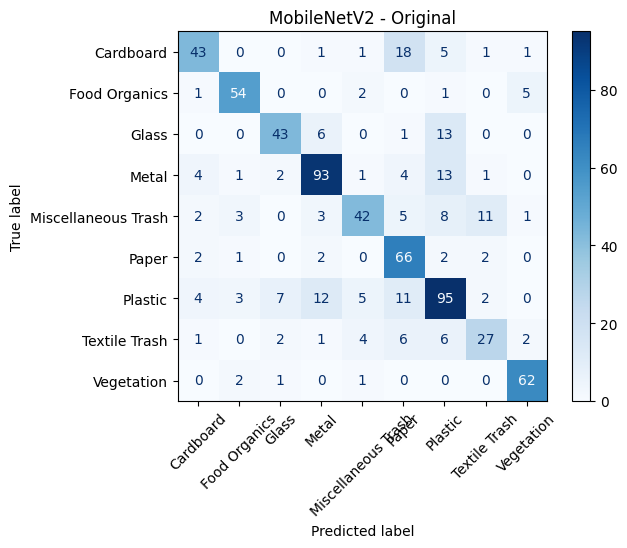

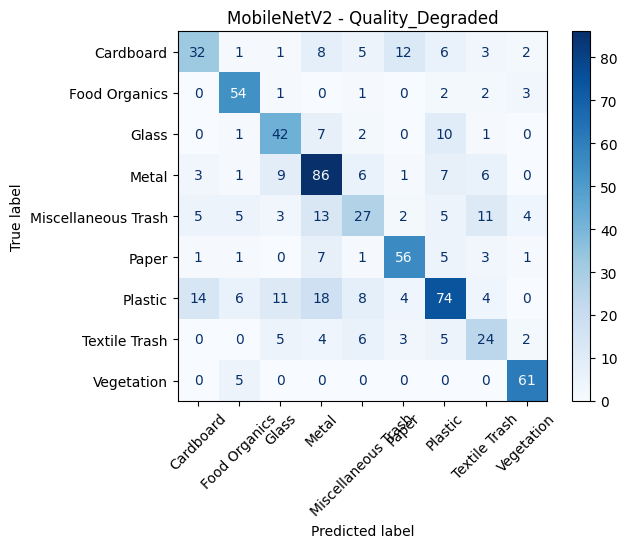

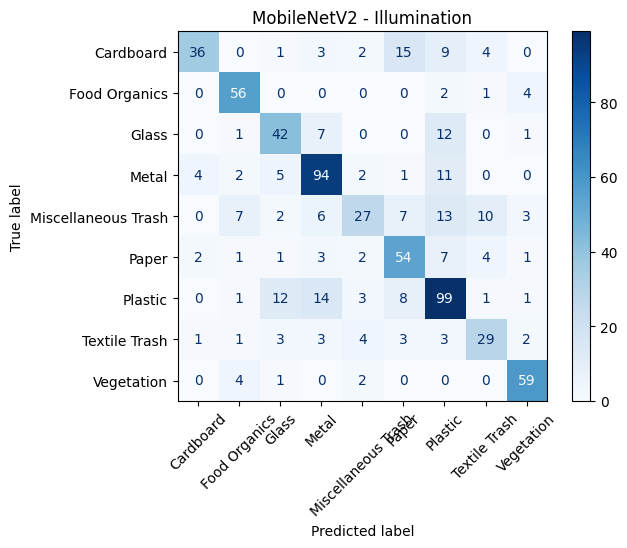

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for dataset_name in mobilenet_predictions:

    cm = confusion_matrix(
        mobilenet_true[dataset_name],
        mobilenet_predictions[dataset_name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(
            data_generators[dataset_name]["train"].class_indices.keys()
        )
    )

    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.title(f"MobileNetV2 - {dataset_name}")

    plt.show()

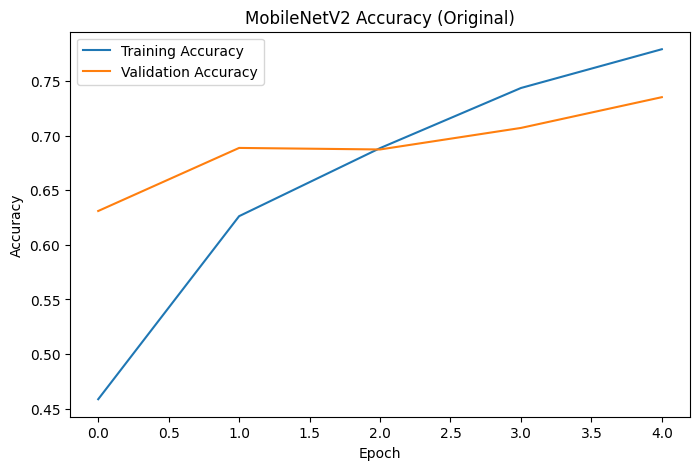

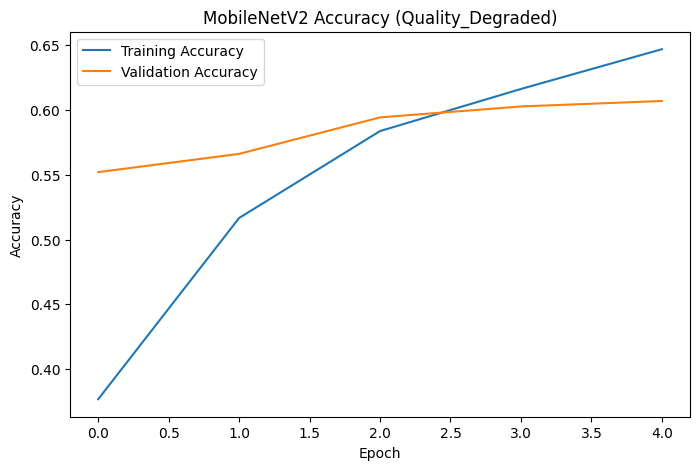

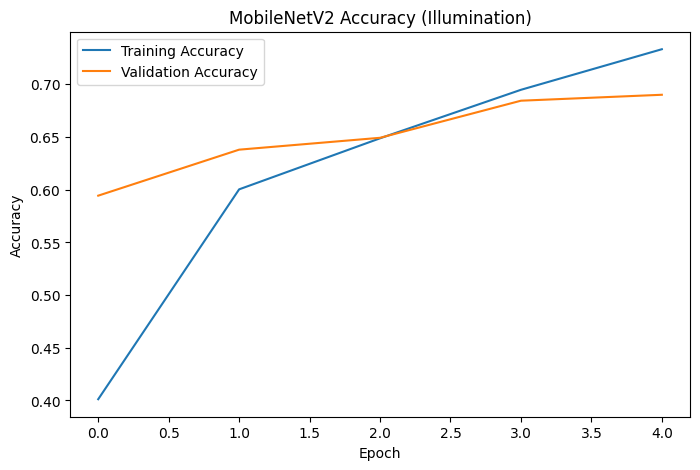

In [26]:
for dataset_name, hist in mobilenet_history.items():

    plt.figure(figsize=(8,5))

    plt.plot(hist.history["accuracy"], label="Training Accuracy")
    plt.plot(hist.history["val_accuracy"], label="Validation Accuracy")

    plt.title(f"MobileNetV2 Accuracy ({dataset_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

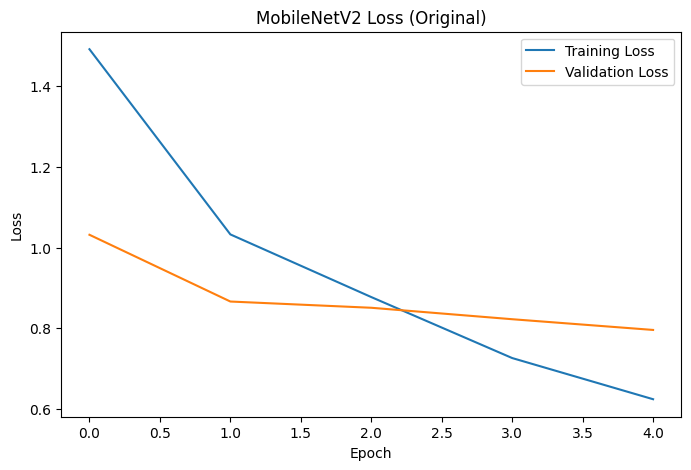

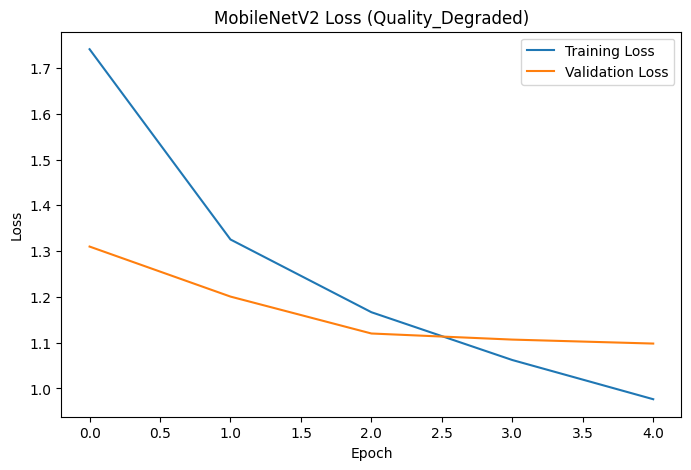

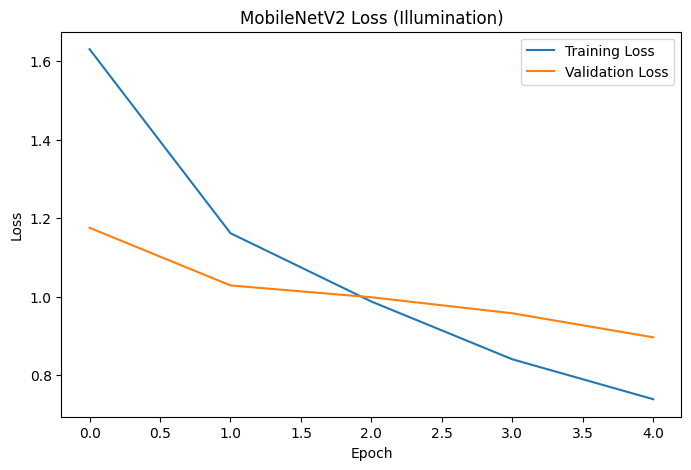

In [27]:
for dataset_name, hist in mobilenet_history.items():

    plt.figure(figsize=(8,5))

    plt.plot(hist.history["loss"], label="Training Loss")
    plt.plot(hist.history["val_loss"], label="Validation Loss")

    plt.title(f"MobileNetV2 Loss ({dataset_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

restnet

In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [11]:
resnet_history = {}

resnet_models = {}

for dataset_name, generators in data_generators.items():

    print(f"\nTraining ResNet50 on {dataset_name} Dataset...\n")

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    # Freeze pretrained layers
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu')(x)

    x = BatchNormalization()(x)

    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)

    x = Dropout(0.3)(x)

    output = Dense(9, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        generators["train"],
        validation_data=generators["validation"],
        epochs=5
    )

    resnet_history[dataset_name] = history
    resnet_models[dataset_name] = model


Training ResNet50 on Original Dataset...

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1256s 12s/step - accuracy: 0.3021 - loss: 1.9590 - val_accuracy: 0.1183 - val_loss: 2.3456
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.3789 - loss: 1.7776 - val_accuracy: 0.1239 - val_loss: 2.6982
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - accuracy: 0.3957 - loss: 1.6756 - val_accuracy: 0.2563 - val_loss: 2.3046
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 176ms/step - accuracy: 0.4156 - loss: 1.5906 - val_accuracy: 0.2535 - val_loss: 3.5603
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.4225 - loss: 1.5670 - val_accuracy: 0.2127 - val_loss: 3.9316

Training ResNet50 on Quality_Degraded Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1514s 14s/step - accuracy: 0.2916 - loss: 1.9755 - val_accuracy: 0.0972 - val_loss: 2.6434
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - accuracy: 0.3659 - 

In [12]:
resnet_finetune_history = {}

for dataset_name, model in resnet_models.items():

    print(f"\nFine-Tuning ResNet50 on {dataset_name} Dataset...\n")

    # Freeze all layers
    for layer in model.layers:
        layer.trainable = False

    # Unfreeze last 20 layers
    for layer in model.layers[-20:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        data_generators[dataset_name]["train"],
        validation_data=data_generators[dataset_name]["validation"],
        epochs=5
    )

    resnet_finetune_history[dataset_name] = history


Fine-Tuning ResNet50 on Original Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 49s 303ms/step - accuracy: 0.3680 - loss: 1.7521 - val_accuracy: 0.1606 - val_loss: 8.2734
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 176ms/step - accuracy: 0.4361 - loss: 1.5427 - val_accuracy: 0.1718 - val_loss: 5.6750
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.4713 - loss: 1.4435 - val_accuracy: 0.2577 - val_loss: 2.3199
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.4938 - loss: 1.3818 - val_accuracy: 0.4338 - val_loss: 1.5542
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.5104 - loss: 1.3253 - val_accuracy: 0.5197 - val_loss: 1.3619

Fine-Tuning ResNet50 on Quality_Degraded Dataset...

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.3485 - loss: 1.8860 - val_accuracy: 0.1775 - val_loss: 12.4519
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.4183 - loss: 1.6304 - val_accuracy: 0.1070 - val_lo

In [13]:
resnet_results = {}

for dataset_name, model in resnet_models.items():

    print(f"\nEvaluating {dataset_name}\n")

    loss, accuracy = model.evaluate(
        data_generators[dataset_name]["test"]
    )

    resnet_results[dataset_name] = {
        "Loss": loss,
        "Accuracy": accuracy
    }

    print(f"Test Accuracy : {accuracy:.4f}")


Evaluating Original

23/23 ━━━━━━━━━━━━━━━━━━━━ 250s 11s/step - accuracy: 0.5021 - loss: 1.3688
Test Accuracy : 0.5021

Evaluating Quality_Degraded

23/23 ━━━━━━━━━━━━━━━━━━━━ 247s 11s/step - accuracy: 0.3644 - loss: 1.6551
Test Accuracy : 0.3644

Evaluating Illumination

23/23 ━━━━━━━━━━━━━━━━━━━━ 250s 11s/step - accuracy: 0.3713 - loss: 1.6618
Test Accuracy : 0.3713


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

resnet_predictions = {}
resnet_true = {}

for dataset_name, model in resnet_models.items():

    test_generator = data_generators[dataset_name]["test"]

    test_generator.reset()

    pred = model.predict(test_generator)

    pred = np.argmax(pred, axis=1)

    true = test_generator.classes

    resnet_predictions[dataset_name] = pred
    resnet_true[dataset_name] = true

23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 356ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 352ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 323ms/step


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

resnet_metrics = {}


for dataset_name in resnet_predictions.keys():

    resnet_metrics[dataset_name] = {

        "Accuracy": accuracy_score(
            resnet_true[dataset_name],
            resnet_predictions[dataset_name]
        ),

        "Precision": precision_score(
            resnet_true[dataset_name],
            resnet_predictions[dataset_name],
            average='weighted'
        ),

        "Recall": recall_score(
            resnet_true[dataset_name],
            resnet_predictions[dataset_name],
            average='weighted'
        ),

        "F1 Score": f1_score(
            resnet_true[dataset_name],
            resnet_predictions[dataset_name],
            average='weighted'
        )
    }

In [20]:
import pandas as pd

# Convert dictionary to DataFrame
resnet_metrics_df = pd.DataFrame(resnet_metrics).T

# Set dataset names as index
resnet_metrics_df.index.name = "Dataset"

# Display the table
print(resnet_metrics_df)

# Save to CSV
resnet_metrics_df.to_csv(
    "/content/drive/MyDrive/Research_Assignment/Results/resnet.csv"
)

print("CSV file saved successfully!")

                  Accuracy  Precision    Recall  F1 Score
Dataset                                                  
Original          0.502086   0.488048  0.502086  0.476374
Quality_Degraded  0.364395   0.447844  0.364395  0.340384
Illumination      0.371349   0.392057  0.371349  0.322559
CSV file saved successfully!


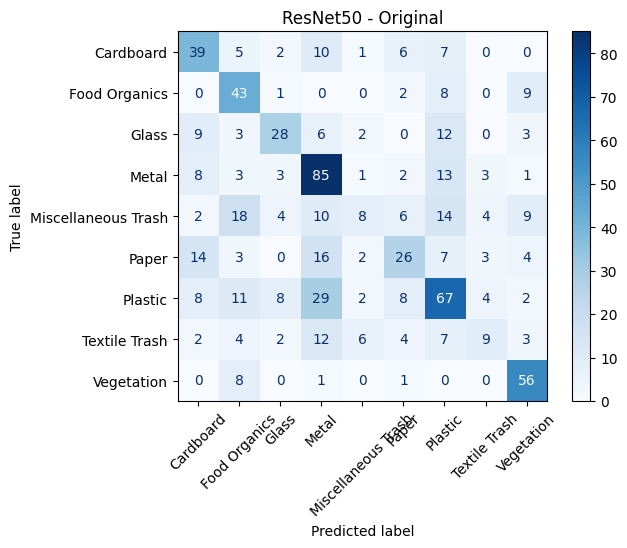

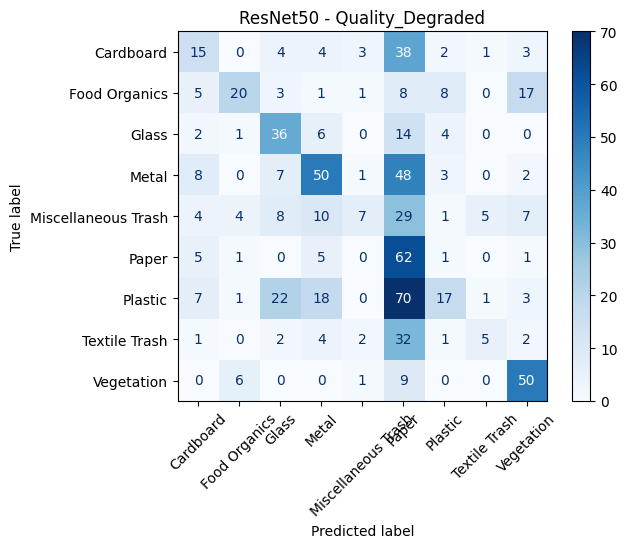

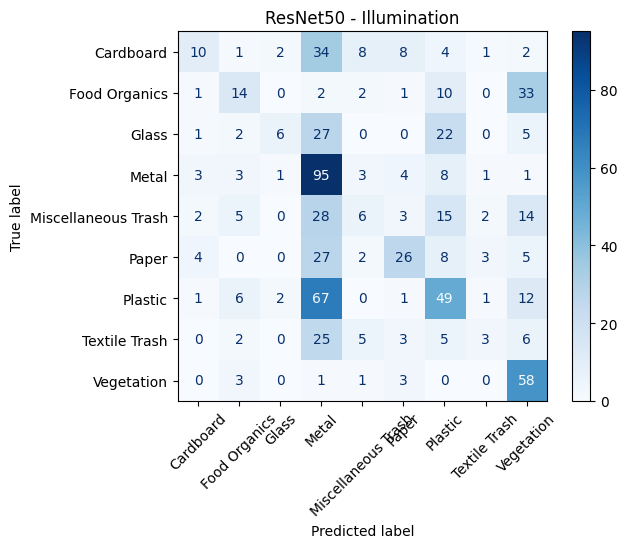

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for dataset_name in resnet_predictions:

    cm = confusion_matrix(
        resnet_true[dataset_name],
        resnet_predictions[dataset_name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(
            data_generators[dataset_name]["train"].class_indices.keys()
        )
    )

    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.title(f"ResNet50 - {dataset_name}")

    plt.show()

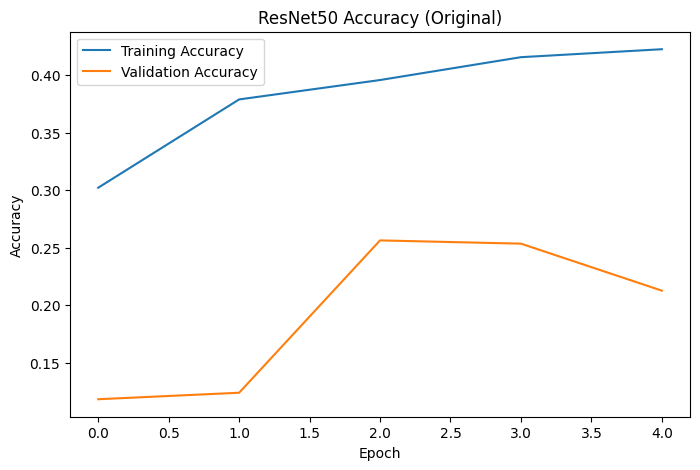

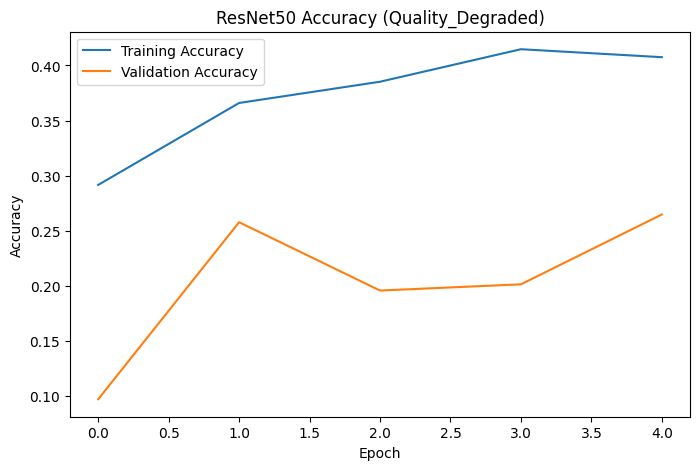

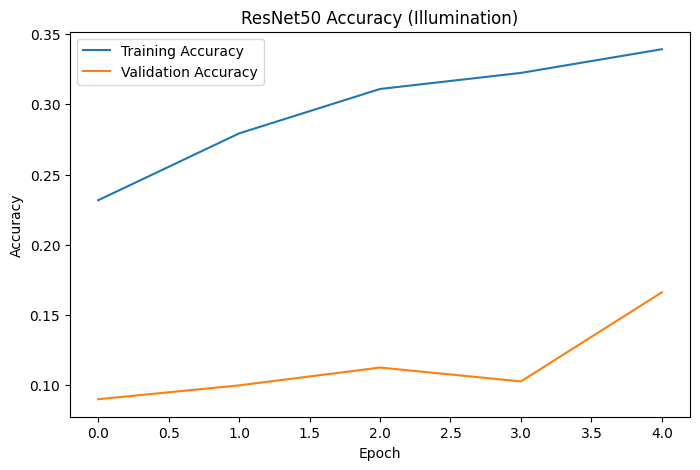

In [22]:
for dataset_name, hist in resnet_history.items():

    plt.figure(figsize=(8,5))

    plt.plot(hist.history["accuracy"], label="Training Accuracy")
    plt.plot(hist.history["val_accuracy"], label="Validation Accuracy")

    plt.title(f"ResNet50 Accuracy ({dataset_name})")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

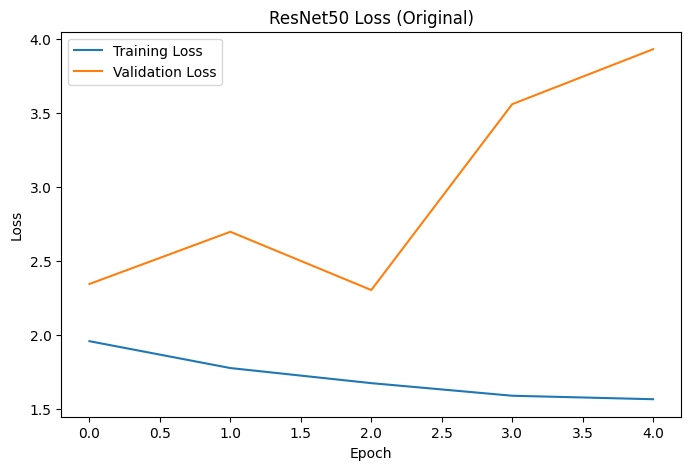

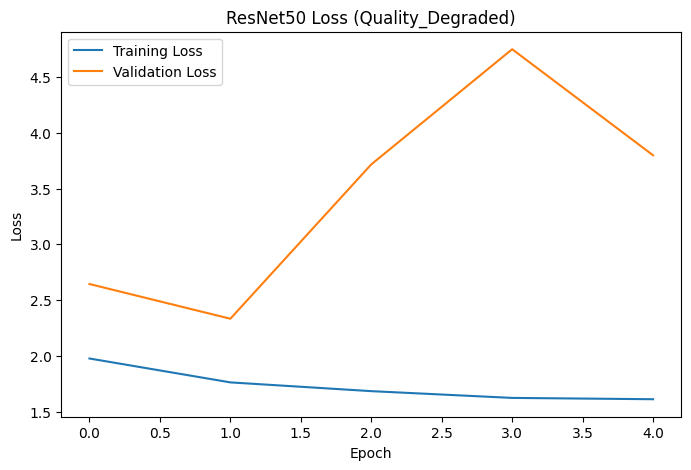

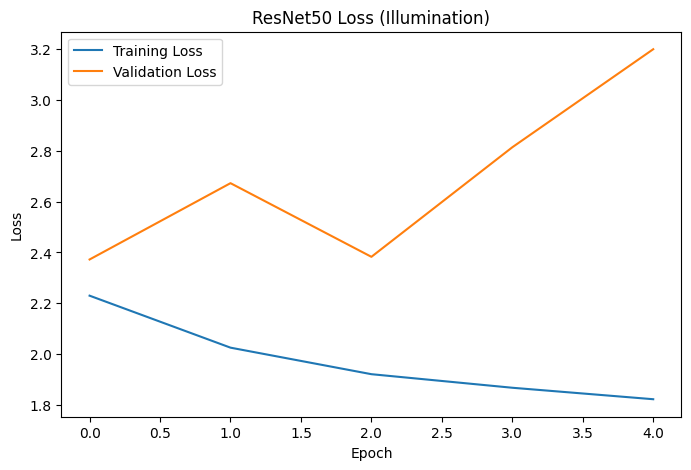

In [23]:
for dataset_name, hist in resnet_history.items():

    plt.figure(figsize=(8,5))

    plt.plot(hist.history["loss"], label="Training Loss")
    plt.plot(hist.history["val_loss"], label="Validation Loss")

    plt.title(f"ResNet50 Loss ({dataset_name})")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    plt.show()

comparision table

In [25]:
import pandas as pd

comparison_results = []

# ------------------- VGG16 -------------------

# for dataset_name in metrics.keys():

#     comparison_results.append({

#         "Model": "VGG16",

#         "Dataset": dataset_name,

#         "Train Accuracy":
#             max(history[dataset_name].history['accuracy']),

#         "Validation Accuracy":
#             max(history[dataset_name].history['val_accuracy']),

#         "Train Loss":
#             min(history[dataset_name].history['loss']),

#         "Validation Loss":
#             min(history[dataset_name].history['val_loss']),

#         "Test Accuracy":
#             metrics[dataset_name]["Accuracy"],

#         "Precision":
#             metrics[dataset_name]["Precision"],

#         "Recall":
#             metrics[dataset_name]["Recall"],

#         "F1 Score":
#             metrics[dataset_name]["F1 Score"]
#     })


# # ---------------- MobileNetV2 ----------------

# for dataset_name in mobilenet_metrics.keys():

#     comparison_results.append({

#         "Model": "MobileNetV2",

#         "Dataset": dataset_name,

#         "Train Accuracy":
#             max(mobilenet_history[dataset_name].history['accuracy']),

#         "Validation Accuracy":
#             max(mobilenet_history[dataset_name].history['val_accuracy']),

#         "Train Loss":
#             min(mobilenet_history[dataset_name].history['loss']),

#         "Validation Loss":
#             min(mobilenet_history[dataset_name].history['val_loss']),

#         "Test Accuracy":
#             mobilenet_metrics[dataset_name]["Accuracy"],

#         "Precision":
#             mobilenet_metrics[dataset_name]["Precision"],

#         "Recall":
#             mobilenet_metrics[dataset_name]["Recall"],

#         "F1 Score":
#             mobilenet_metrics[dataset_name]["F1 Score"]
#     })


# ----------------- ResNet50 ------------------

for dataset_name in resnet_metrics.keys():

    comparison_results.append({

        "Model": "ResNet50",

        "Dataset": dataset_name,

        "Train Accuracy":
            max(resnet_history[dataset_name].history['accuracy']),

        "Validation Accuracy":
            max(resnet_history[dataset_name].history['val_accuracy']),

        "Train Loss":
            min(resnet_history[dataset_name].history['loss']),

        "Validation Loss":
            min(resnet_history[dataset_name].history['val_loss']),

        "Test Accuracy":
            resnet_metrics[dataset_name]["Accuracy"],

        "Precision":
            resnet_metrics[dataset_name]["Precision"],

        "Recall":
            resnet_metrics[dataset_name]["Recall"],

        "F1 Score":
            resnet_metrics[dataset_name]["F1 Score"]
    })


comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Model,Dataset,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss,Test Accuracy,Precision,Recall,F1 Score
0,ResNet50,Original,0.422510,0.256338,1.566999,2.304633,0.502086,0.488048,0.502086,0.476374
1,ResNet50,Quality_Degraded,0.414686,0.264789,1.610263,2.332203,0.364395,0.447844,0.364395,0.340384
2,ResNet50,Illumination,0.339151,0.166197,1.823542,2.372407,0.371349,0.392057,0.371349,0.322559


In [ ]:
comparison_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

In [ ]:
comparison_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

In [ ]:
best_models = comparison_df.loc[
    comparison_df.groupby("Dataset")["Test Accuracy"].idxmax()
]

best_models

In [ ]:
average_results = comparison_df.groupby("Model").mean(
    numeric_only=True
)

average_results

In [ ]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(8,5))

    for model in comparison_df["Model"].unique():

        model_data = comparison_df[
            comparison_df["Model"] == model
        ]

        plt.plot(
            model_data["Dataset"],
            model_data[metric],
            marker="o",
            label=model
        )

    plt.title(f"{metric} Comparison")
    plt.xlabel("Dataset Version")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for model in comparison_df["Model"].unique():

    temp = comparison_df[comparison_df["Model"] == model]

    plt.plot(
        temp["Dataset"],
        temp["Test Accuracy"],
        marker='o',
        linewidth=2,
        label=model
    )

plt.title("Test Accuracy Comparison")

plt.xlabel("Dataset")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

for model in comparison_df["Model"].unique():

    temp = comparison_df[comparison_df["Model"] == model]

    plt.plot(
        temp["Dataset"],
        temp["Train Accuracy"],
        marker='o',
        linewidth=2,
        label=model
    )

plt.title("Training Accuracy Comparison")

plt.xlabel("Dataset")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

for model in comparison_df["Model"].unique():

    temp = comparison_df[comparison_df["Model"] == model]

    plt.plot(
        temp["Dataset"],
        temp["Validation Accuracy"],
        marker='o',
        linewidth=2,
        label=model
    )

plt.title("Validation Accuracy Comparison")

plt.xlabel("Dataset")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

for model in comparison_df["Model"].unique():

    temp = comparison_df[comparison_df["Model"] == model]

    plt.plot(
        temp["Dataset"],
        temp["Train Loss"],
        marker='o',
        linewidth=2,
        label=model
    )

plt.title("Training Loss Comparison")

plt.xlabel("Dataset")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

for model in comparison_df["Model"].unique():

    temp = comparison_df[comparison_df["Model"] == model]

    plt.plot(
        temp["Dataset"],
        temp["Validation Loss"],
        marker='o',
        linewidth=2,
        label=model
    )

plt.title("Validation Loss Comparison")

plt.xlabel("Dataset")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import numpy as np

pivot = comparison_df.pivot(
    index="Dataset",
    columns="Model",
    values="Test Accuracy"
)

pivot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Overall Test Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [ ]:
import pandas as pd

comparison_data = []

# ---------------- VGG16 ----------------

for dataset_name in metrics.keys():

    comparison_data.append({

        "Model": "VGG16",

        "Dataset": dataset_name,

        "Training Accuracy":
            max(history[dataset_name].history["accuracy"]),

        "Validation Accuracy":
            max(history[dataset_name].history["val_accuracy"]),

        "Training Loss":
            min(history[dataset_name].history["loss"]),

        "Validation Loss":
            min(history[dataset_name].history["val_loss"]),

        "Accuracy":
            metrics[dataset_name]["Accuracy"],

        "Precision":
            metrics[dataset_name]["Precision"],

        "Recall":
            metrics[dataset_name]["Recall"],

        "F1 Score":
            metrics[dataset_name]["F1 Score"]
    })



# ---------------- MobileNetV2 ----------------

for dataset_name in mobilenet_metrics.keys():

    comparison_data.append({

        "Model": "MobileNetV2",

        "Dataset": dataset_name,

        "Training Accuracy":
            max(mobilenet_history[dataset_name].history["accuracy"]),

        "Validation Accuracy":
            max(mobilenet_history[dataset_name].history["val_accuracy"]),

        "Training Loss":
            min(mobilenet_history[dataset_name].history["loss"]),

        "Validation Loss":
            min(mobilenet_history[dataset_name].history["val_loss"]),

        "Accuracy":
            mobilenet_metrics[dataset_name]["Accuracy"],

        "Precision":
            mobilenet_metrics[dataset_name]["Precision"],

        "Recall":
            mobilenet_metrics[dataset_name]["Recall"],

        "F1 Score":
            mobilenet_metrics[dataset_name]["F1 Score"]
    })



# ---------------- ResNet50 ----------------

for dataset_name in resnet_metrics.keys():

    comparison_data.append({

        "Model": "ResNet50",

        "Dataset": dataset_name,

        "Training Accuracy":
            max(resnet_history[dataset_name].history["accuracy"]),

        "Validation Accuracy":
            max(resnet_history[dataset_name].history["val_accuracy"]),

        "Training Loss":
            min(resnet_history[dataset_name].history["loss"]),

        "Validation Loss":
            min(resnet_history[dataset_name].history["val_loss"]),

        "Accuracy":
            resnet_metrics[dataset_name]["Accuracy"],

        "Precision":
            resnet_metrics[dataset_name]["Precision"],

        "Recall":
            resnet_metrics[dataset_name]["Recall"],

        "F1 Score":
            resnet_metrics[dataset_name]["F1 Score"]
    })


comparison_df = pd.DataFrame(comparison_data)

comparison_df.to_csv(
    "Transfer_Learning_Model_Comparison.csv",
    index=False
)

print(comparison_df)

print("\nCSV file saved successfully.")